# Melanoma Detection — Derm7pt Dataset
### MobileNetV2 vs ResNet50 — Feature-Space SMOTE | 3-Run Experiment
**Dataset:** Derm7pt (7-Point Criteria Evaluation Dataset) — Menaka Mohanakumar

**Image strategy:** Dermoscopy images primary; clinical image used as fallback if dermoscopy missing.
**Label strategy:** Melanoma = malignant. All other diagnoses = benign. Non-melanoma malignant cases excluded.
**Split:** Official train+valid indexes for training, official test indexes for evaluation.

**Metrics:** Accuracy · Sensitivity · PPV · NPV · AUC · F1 · Inference Time · Model Size

## 1. Imports

In [1]:
import os, itertools, time, gc
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('whitegrid')

from sklearn.metrics import (confusion_matrix, classification_report,
                             recall_score, roc_curve, auc)
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2026-03-13 22:29:40.020046: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773440980.362156      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773440980.460131      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773440981.197071      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773440981.197120      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773440981.197123      17 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPU available: []


2026-03-13 22:30:10.410271: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Discover Dataset Structure

In [2]:
base = '/kaggle/input/derm7pt'
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    if level <= 3:
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")

## 3. Configuration & Paths

In [3]:
BASE_DIR = '/kaggle/input/datasets/menakamohanakumar/derm7pt/release_v0'
IMAGE_DIR = os.path.join(BASE_DIR, 'images')
META_CSV  = os.path.join(BASE_DIR, 'meta', 'meta.csv')
TRAIN_IDX = os.path.join(BASE_DIR, 'meta', 'train_indexes.csv')
VALID_IDX = os.path.join(BASE_DIR, 'meta', 'valid_indexes.csv')
TEST_IDX  = os.path.join(BASE_DIR, 'meta', 'test_indexes.csv')

TARGET_PER_CLASS = 5000
RANDOM_STATE     = 42
IMG_SIZE         = (224, 224)
CHANNELS         = 3
IMG_SHAPE        = (IMG_SIZE[0], IMG_SIZE[1], CHANNELS)
BATCH_SIZE       = 16
EPOCHS           = 20
N_RUNS           = 3
SMOTE_BATCH      = 200

print(f"Image dir    : {IMAGE_DIR}")
print(f"Meta CSV     : {META_CSV}")
print(f"Image shape  : {IMG_SHAPE}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Epochs       : {EPOCHS}")
print(f"Runs         : {N_RUNS}")

Image dir    : /kaggle/input/datasets/menakamohanakumar/derm7pt/release_v0/images
Meta CSV     : /kaggle/input/datasets/menakamohanakumar/derm7pt/release_v0/meta/meta.csv
Image shape  : (224, 224, 3)
Batch size   : 16
Epochs       : 20
Runs         : 3


In [4]:
import os
os.listdir('/kaggle/input/datasets/menakamohanakumar/derm7pt')

['release_v0']

## 4. Load & Inspect Metadata

In [5]:
meta = pd.read_csv(META_CSV)
print("Shape   :", meta.shape)
print("Columns :", meta.columns.tolist())
print()
meta.head()

Shape   : (1011, 19)
Columns : ['case_num', 'diagnosis', 'seven_point_score', 'pigment_network', 'streaks', 'pigmentation', 'regression_structures', 'dots_and_globules', 'blue_whitish_veil', 'vascular_structures', 'level_of_diagnostic_difficulty', 'elevation', 'location', 'sex', 'management', 'clinic', 'derm', 'case_id', 'notes']



,case_num,diagnosis,seven_point_score,pigment_network,streaks,pigmentation,regression_structures,dots_and_globules,blue_whitish_veil,vascular_structures,level_of_diagnostic_difficulty,elevation,location,sex,management,clinic,derm,case_id,notes
0,1,basal cell carcinoma,0,absent,absent,absent,absent,absent,absent,arborizing,medium,nodular,abdomen,female,excision,NEL/NEL025.JPG,NEL/Nel026.jpg,NaN,NaN
1,2,basal cell carcinoma,1,absent,absent,absent,absent,irregular,absent,absent,low,palpable,head neck,female,excision,NEL/NEL027.JPG,NEL/Nel028.jpg,NaN,NaN
2,3,basal cell carcinoma,1,absent,absent,absent,absent,irregular,absent,arborizing,medium,palpable,head neck,female,excision,NEL/Nel032.jpg,NEL/Nel033.jpg,NaN,NaN
3,4,basal cell carcinoma,4,absent,absent,absent,blue areas,irregular,present,within regression,low,palpable,lower limbs,male,excision,NEL/NEL034.JPG,NEL/Nel035.jpg,NaN,NaN
4,5,basal cell carcinoma,1,absent,absent,diffuse irregular,absent,absent,absent,absent,high,palpable,upper limbs,female,excision,NEL/NEL036.JPG,NEL/Nel037.jpg,NaN,NaN


## 5. Identify Key Columns

In [6]:
# Auto-detect diagnosis column
diag_col = None
for col in ['diagnosis', 'Diagnosis', 'label', 'Label', 'diag']:
    if col in meta.columns:
        diag_col = col; break

# Auto-detect image columns
derm_col = clinic_col = None
for col in meta.columns:
    cl = col.lower()
    if 'derm' in cl:
        derm_col = col
    if 'clinic' in cl:
        clinic_col = col

print(f"Diagnosis col : {diag_col}")
print(f"Derm img col  : {derm_col}")
print(f"Clinic img col: {clinic_col}")

if diag_col:
    print("\nDiagnosis value counts:")
    print(meta[diag_col].value_counts())

if derm_col:
    print("\nSample derm values:", meta[derm_col].head(5).tolist())
if clinic_col:
    print("Sample clinic values:", meta[clinic_col].head(5).tolist())

Diagnosis col : diagnosis
Derm img col  : derm
Clinic img col: clinic

Diagnosis value counts:
diagnosis
clark nevus                     399
melanoma (less than 0.76 mm)    102
reed or spitz nevus              79
melanoma (in situ)               64
melanoma (0.76 to 1.5 mm)        53
seborrheic keratosis             45
basal cell carcinoma             42
dermal nevus                     33
vascular lesion                  29
blue nevus                       28
melanoma (more than 1.5 mm)      28
lentigo                          24
dermatofibroma                   20
congenital nevus                 17
melanosis                        16
combined nevus                   13
miscellaneous                     8
recurrent nevus                   6
melanoma metastasis               4
melanoma                          1
Name: count, dtype: int64

Sample derm values: ['NEL/Nel026.jpg', 'NEL/Nel028.jpg', 'NEL/Nel033.jpg', 'NEL/Nel035.jpg', 'NEL/Nel037.jpg']
Sample clinic values: ['NEL/NEL025.JP

## 6. Build Filepaths & Binary Labels

> **Note:** Update `DIAG_COL`, `DERM_COL`, `CLINIC_COL` below if Cell 5 shows different column names.
> Also update `MELANOMA_STR` if the melanoma label uses different capitalisation in your dataset.

In [7]:
# ── Update these if needed based on Cell 5 output ────────────────────────
DIAG_COL     = diag_col      # e.g. 'diagnosis'
DERM_COL     = derm_col      # e.g. 'derm_image' or 'derm'
CLINIC_COL   = clinic_col    # e.g. 'clinic_image' or 'clinic'
MELANOMA_STR = 'melanoma'    # exact string (lowercased) used for melanoma in diagnosis col

# ── Benign diagnosis strings (add more if needed) ─────────────────────────
BENIGN_STRS = {
    'nevus', 'nv', 'seborrheic keratosis', 'sk', 'bkl',
    'dermatofibroma', 'df', 'vascular lesion', 'vasc',
    'benign keratosis', 'lentigo nos', 'lentigo simplex',
    'solar lentigo', 'pigmented benign keratosis', 'miscellaneous',
    'lichen planus-like keratosis'
}

def find_image_path(row, image_dir, derm_col, clinic_col):
    for col in [c for c in [derm_col, clinic_col] if c]:
        val = row.get(col)
        if pd.isna(val):
            continue
        fname = str(val).strip()
        for suffix in ['', '.jpg', '.jpeg', '.png']:
            fp = os.path.join(image_dir, fname + suffix)
            if os.path.exists(fp):
                return fp
    return None

def map_label(d):
    d = str(d).lower().strip()
    if MELANOMA_STR in d:
        return 'malignant'
    for b in BENIGN_STRS:
        if b in d:
            return 'benign'
    return None  # excluded

meta['filepaths'] = meta.apply(lambda r: find_image_path(r, IMAGE_DIR, DERM_COL, CLINIC_COL), axis=1)
meta['labels']    = meta[DIAG_COL].apply(map_label)

print("Label distribution (all rows):")
print(meta['labels'].value_counts(dropna=False))
print(f"\nExcluded (non-melanoma malignant / unknown): {meta['labels'].isna().sum()}")
print(f"Missing filepaths: {meta['filepaths'].isna().sum()}")

# Verify file paths
exist_check = meta[meta['filepaths'].notna()]['filepaths'].head(10).apply(os.path.exists)
print(f"\nFile existence check (first 10 found): {exist_check.tolist()}")

Label distribution (all rows):
labels
benign       677
malignant    252
None          82
Name: count, dtype: int64

Excluded (non-melanoma malignant / unknown): 82
Missing filepaths: 0

File existence check (first 10 found): [True, True, True, True, True, True, True, True, True, True]


## 7. Apply Official Train / Valid / Test Splits

In [8]:
train_idx = pd.read_csv(TRAIN_IDX)
valid_idx = pd.read_csv(VALID_IDX)
test_idx  = pd.read_csv(TEST_IDX)

print("Index file columns:", train_idx.columns.tolist())
print("Train:", len(train_idx), "| Valid:", len(valid_idx), "| Test:", len(test_idx))

idx_col = train_idx.columns[0]
train_set = set(train_idx[idx_col].values)
valid_set = set(valid_idx[idx_col].values)
test_set  = set(test_idx[idx_col].values)

# Filter valid labelled rows with filepaths
meta_ok = meta[meta['labels'].notna() & meta['filepaths'].notna()].copy()

# Use row index (0-based) to match — reset_index not applied so index = original CSV row
train_df = meta_ok[meta_ok.index.isin(train_set | valid_set)][['filepaths','labels']].copy()
test_df  = meta_ok[meta_ok.index.isin(test_set)][['filepaths','labels']].copy()

train_df = train_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
test_df  = test_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"\nTrain set (train + valid combined):")
print(train_df['labels'].value_counts())
print(f"\nTest set:")
print(test_df['labels'].value_counts())

Index file columns: ['indexes']
Train: 413 | Valid: 203 | Test: 395

Train set (train + valid combined):
labels
benign       417
malignant    151
Name: count, dtype: int64

Test set:
labels
benign       260
malignant    101
Name: count, dtype: int64


## 8. Class Distribution

/tmp/ipykernel_17/2461411106.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette=colors, ax=ax)
/tmp/ipykernel_17/2461411106.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette=colors, ax=ax)


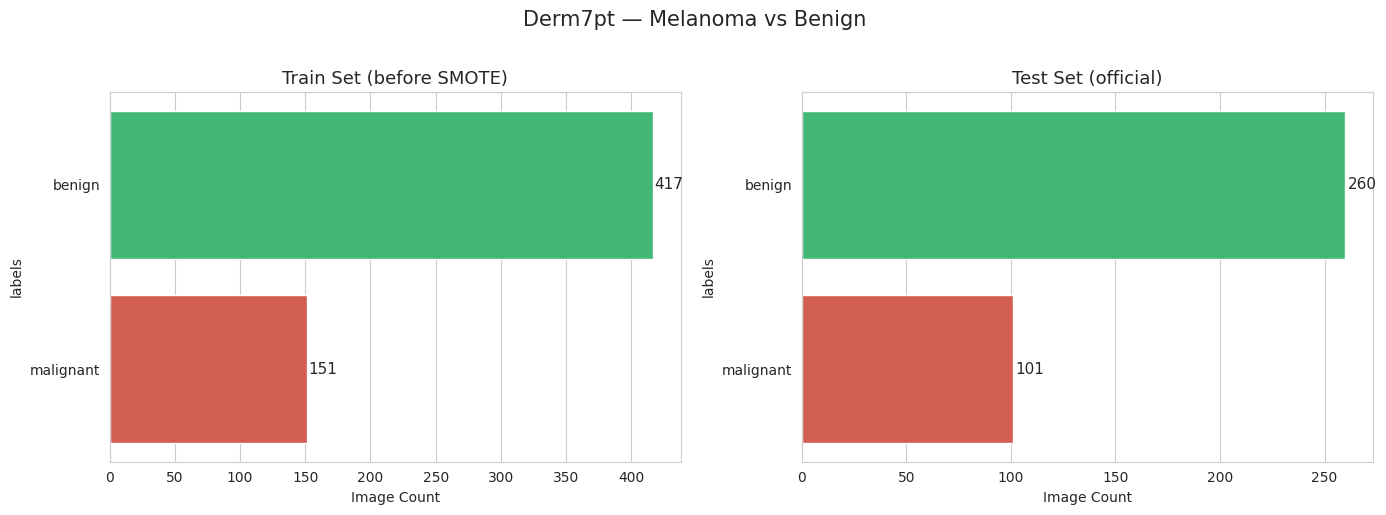

Train imbalance: 417 / 151 = 2.76x
Total train: 568 | Total test: 361


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in zip(axes, [train_df, test_df],
                         ['Train Set (before SMOTE)', 'Test Set (official)']):
    counts = df['labels'].value_counts()
    colors = ['#e74c3c' if l == 'malignant' else '#2ecc71' for l in counts.index]
    sns.barplot(x=counts.values, y=counts.index, palette=colors, ax=ax)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Image Count')
    for i, v in enumerate(counts.values):
        ax.text(v + 1, i, str(v), va='center', fontsize=11)
plt.suptitle('Derm7pt — Melanoma vs Benign', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

ratio = train_df['labels'].value_counts()
print(f"Train imbalance: {ratio.max()} / {ratio.min()} = {ratio.max()/ratio.min():.2f}x")
print(f"Total train: {len(train_df)} | Total test: {len(test_df)}")

## 9. Feature-Space SMOTE

In [10]:
def extract_embeddings(df, img_size=IMG_SIZE, batch_size=SMOTE_BATCH):
    extractor = MobileNetV2(include_top=False, weights='imagenet',
                            input_shape=(img_size[0], img_size[1], 3), pooling='avg')
    extractor.trainable = False

    all_embeddings, valid_indices = [], []
    filepaths = df['filepaths'].values

    for start in range(0, len(filepaths), batch_size):
        batch_paths = filepaths[start:start + batch_size]
        batch_imgs, batch_idxs = [], []
        for i, fp in enumerate(batch_paths):
            img = cv2.imread(fp)
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size).astype(np.float32) / 255.0
            batch_imgs.append(img)
            batch_idxs.append(start + i)
        if not batch_imgs: continue
        embeddings = extractor.predict(np.array(batch_imgs), verbose=0)
        all_embeddings.append(embeddings)
        valid_indices.extend(batch_idxs)
        if (start // batch_size) % 3 == 0:
            print(f"  Extracted {min(start+batch_size, len(filepaths))}/{len(filepaths)} images...")

    del extractor; gc.collect()
    return np.vstack(all_embeddings), df.iloc[valid_indices].reset_index(drop=True)


def apply_feature_smote(train_df, img_size=IMG_SIZE):
    class_counts   = train_df['labels'].value_counts()
    majority_class = class_counts.idxmax()
    minority_class = class_counts.idxmin()
    target         = class_counts[majority_class]

    print(f"Before SMOTE: {majority_class}={class_counts[majority_class]}, {minority_class}={class_counts[minority_class]}")
    print(f"Synthetic to generate: {target - class_counts[minority_class]}")

    print("\nExtracting embeddings...")
    X_emb, df_valid = extract_embeddings(train_df, img_size=img_size)

    unique_labels = sorted(df_valid['labels'].unique())
    y_encoded     = np.array([unique_labels.index(l) for l in df_valid['labels']])

    print(f"Embedding matrix: {X_emb.shape}  ({X_emb.nbytes/1e6:.1f} MB)")
    sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=5,
               sampling_strategy={unique_labels.index(minority_class): target})
    X_res, y_res = sm.fit_resample(X_emb, y_encoded)
    n_original  = len(df_valid)
    n_synthetic = len(X_res) - n_original
    print(f"After SMOTE: {len(X_res)} total  ({n_synthetic} synthetic images)")

    minority_mask = y_encoded == unique_labels.index(minority_class)
    knn = NearestNeighbors(n_neighbors=2, metric='euclidean')
    knn.fit(X_emb[minority_mask])
    df_minority = df_valid[minority_mask].reset_index(drop=True)

    smote_dir = '/kaggle/working/smote_synthetic'
    os.makedirs(smote_dir, exist_ok=True)

    new_filepaths = list(df_valid['filepaths'])
    new_labels    = list(df_valid['labels'])

    print("Generating synthetic images via pixel blending...")
    dists_all, idxs_all = knn.kneighbors(X_res[n_original:])

    for k in range(n_synthetic):
        fp1 = df_minority.iloc[idxs_all[k][0]]['filepaths']
        fp2 = df_minority.iloc[idxs_all[k][1]]['filepaths']
        img1 = cv2.imread(fp1)
        img2 = cv2.imread(fp2)
        if img1 is None or img2 is None: continue
        img1 = cv2.resize(img1, img_size).astype(np.float32)
        img2 = cv2.resize(img2, img_size).astype(np.float32)
        d1, d2 = dists_all[k][0] + 1e-8, dists_all[k][1] + 1e-8
        w1     = d2 / (d1 + d2)
        blended = (w1 * img1 + (1 - w1) * img2).astype(np.uint8)
        fname   = os.path.join(smote_dir, f'synthetic_{k}.png')
        cv2.imwrite(fname, blended)
        new_filepaths.append(fname)
        new_labels.append(minority_class)
        if k % 100 == 0:
            print(f"  Saved {k}/{n_synthetic} synthetic images...")

    del X_emb, X_res; gc.collect()

    balanced_df = pd.DataFrame({'filepaths': new_filepaths, 'labels': new_labels})
    balanced_df = balanced_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    print("\nFinal class distribution:")
    print(balanced_df['labels'].value_counts())
    return balanced_df

train_df_balanced = apply_feature_smote(train_df)

Before SMOTE: benign=417, malignant=151
Synthetic to generate: 266

Extracting embeddings...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
  Extracted 200/568 images...
Embedding matrix: (568, 1280)  (2.9 MB)
After SMOTE: 834 total  (266 synthetic images)
Generating synthetic images via pixel blending...
  Saved 0/266 synthetic images...
  Saved 100/266 synthetic images...
  Saved 200/266 synthetic images...

Final class distribution:
labels
malignant    417
benign       417
Name: count, dtype: int64


## 10. Preview Balanced Dataset

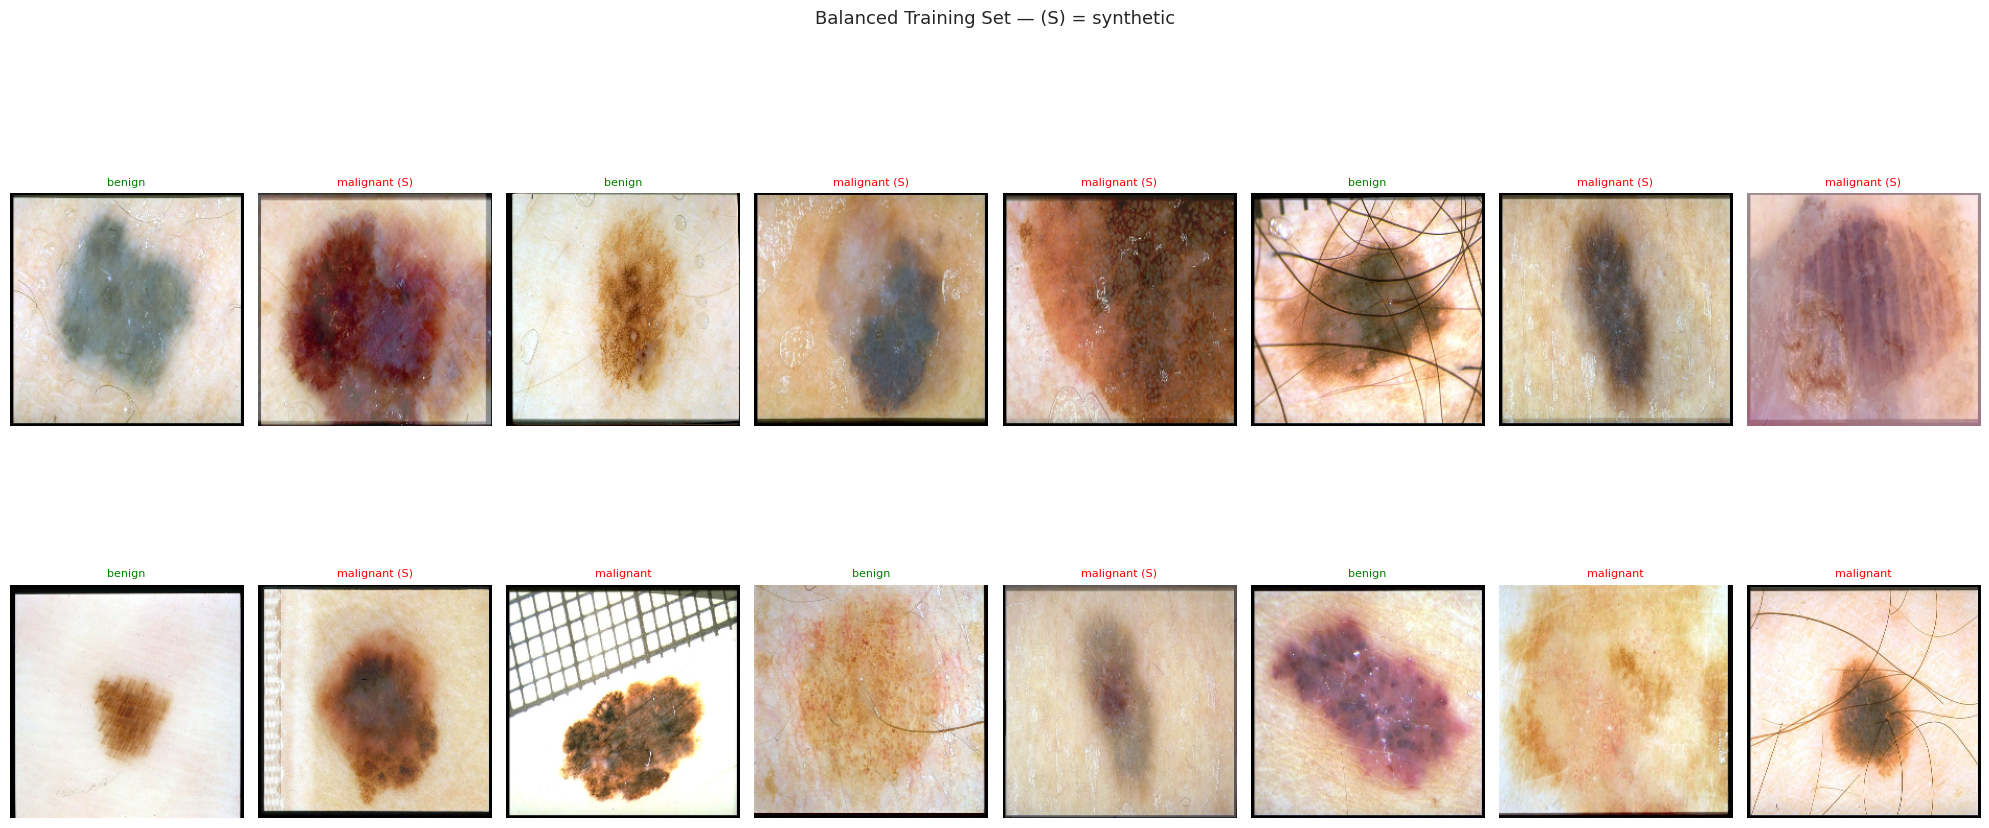

In [11]:
sample = train_df_balanced.sample(16, random_state=1).reset_index(drop=True)
plt.figure(figsize=(20, 10))
for i, row in sample.iterrows():
    img = cv2.imread(row['filepaths'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    plt.subplot(2, 8, i + 1)
    plt.imshow(img / 255.)
    synth = ' (S)' if 'synthetic' in row['filepaths'] else ''
    plt.title(row['labels'] + synth, fontsize=8,
              color='red' if row['labels'] == 'malignant' else 'green')
    plt.axis('off')
plt.suptitle('Balanced Training Set — (S) = synthetic', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Helper Functions

In [12]:
def build_generators(train_df_b, test_df, img_size=IMG_SIZE, batch_size=BATCH_SIZE):
    tr_gen = ImageDataGenerator()
    ts_gen = ImageDataGenerator()
    train_gen = tr_gen.flow_from_dataframe(
        dataframe=train_df_b, x_col='filepaths', y_col='labels',
        target_size=img_size, class_mode='categorical',
        color_mode='rgb', shuffle=True, batch_size=batch_size)
    test_gen = ts_gen.flow_from_dataframe(
        dataframe=test_df, x_col='filepaths', y_col='labels',
        target_size=img_size, class_mode='categorical',
        color_mode='rgb', shuffle=False, batch_size=batch_size)
    return train_gen, test_gen

def compute_npv_ppv(cm):
    TN, FP, FN, TP = cm.ravel()
    PPV = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    NPV = TN / (TN + FN) if (TN + FN) > 0 else 0.0
    return PPV, NPV

def build_mobilenetv2(img_shape, class_count):
    base = MobileNetV2(include_top=False, weights='imagenet', input_shape=img_shape, pooling='max')
    base.trainable = False
    m = Sequential([base, BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
                    Dense(512, activation='relu'), Dropout(0.5),
                    Dense(class_count, activation='softmax')])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_resnet50(img_shape, class_count):
    base = ResNet50(include_top=False, weights='imagenet', input_shape=img_shape, pooling='max')
    base.trainable = False
    m = Sequential([base, BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
                    Dense(512, activation='relu'), Dropout(0.5),
                    Dense(class_count, activation='softmax')])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def plot_history(history, model_name, run):
    train_acc  = history.history['accuracy']
    train_loss = history.history['loss']
    val_acc    = history.history['val_accuracy']
    val_loss   = history.history['val_loss']
    Epochs     = list(range(1, len(train_acc) + 1))
    i_loss, i_acc = np.argmin(val_loss), np.argmax(val_acc)
    plt.figure(figsize=(20, 8))
    plt.style.use('fivethirtyeight')
    plt.subplot(1, 2, 1)
    plt.plot(Epochs, train_loss, 'r', label='Train Loss')
    plt.plot(Epochs, val_loss,   'g', label='Val Loss')
    plt.scatter(i_loss+1, val_loss[i_loss], s=150, c='blue', label=f'Best epoch={i_loss+1}')
    plt.title(f'{model_name} Loss (Run {run})'); plt.xlabel('Epochs'); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(Epochs, train_acc, 'r', label='Train Accuracy')
    plt.plot(Epochs, val_acc,   'g', label='Val Accuracy')
    plt.scatter(i_acc+1, val_acc[i_acc], s=150, c='blue', label=f'Best epoch={i_acc+1}')
    plt.title(f'{model_name} Accuracy (Run {run})'); plt.xlabel('Epochs'); plt.legend()
    plt.tight_layout(); plt.show()

def evaluate_model(model, test_gen, classes, model_name, run):
    preds  = model.predict(test_gen)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes
    report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
    print(classification_report(y_true, y_pred, target_names=classes))
    sensitivity = recall_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    PPV, NPV = compute_npv_ppv(cm)
    fpr, tpr, _ = roc_curve(y_true, preds[:, 1])
    roc_auc = auc(fpr, tpr)
    t0 = time.time(); model.predict(test_gen)
    inf_time = (time.time() - t0) / len(test_gen.filenames)
    ts_length = len(test_gen.filenames)
    tb = max(sorted([ts_length // n for n in range(1, ts_length + 1)
                     if ts_length % n == 0 and ts_length / n <= 80]))
    test_score = model.evaluate(test_gen, steps=ts_length // tb, verbose=1)

    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'{model_name} Confusion Matrix (Run {run})')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45); plt.yticks(tick_marks, classes)
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], ha='center', color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout(); plt.ylabel('True Label'); plt.xlabel('Predicted Label'); plt.show()

    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve (Run {run})'); plt.legend(loc='lower right'); plt.show()

    metrics = {
        'test_loss': test_score[0], 'test_accuracy': test_score[1],
        'sensitivity': sensitivity, 'PPV': PPV, 'NPV': NPV, 'AUC': roc_auc,
        'inference_time': inf_time,
        'f1_benign': report['benign']['f1-score'],
        'f1_malignant': report['malignant']['f1-score'],
        'precision_benign': report['benign']['precision'],
        'recall_benign': report['benign']['recall'],
        'precision_malignant': report['malignant']['precision'],
        'recall_malignant': report['malignant']['recall'],
    }
    print(f"\n{'='*50}  {model_name} Run {run}")
    for k, v in metrics.items(): print(f"  {k:<28}: {v:.4f}")
    return metrics

print("Helper functions defined ✓")

Helper functions defined ✓


## 12. Run Experiments (3 Runs x 2 Models)


############################################################
  RUN 1 / 3
############################################################

Found 834 validated image filenames belonging to 2 classes.
Found 361 validated image filenames belonging to 2 classes.

--- MobileNetV2 (Run 1) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,920,002 (11.14 MB)

 Trainable params: 659,458 (2.52 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 412ms/step - accuracy: 0.6520 - loss: 0.8897 - val_accuracy: 0.3463 - val_loss: 3.1494
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 461ms/step - accuracy: 0.8773 - loss: 0.3260 - val_accuracy: 0.5125 - val_loss: 1.7476
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 377ms/step - accuracy: 0.8862 - loss: 0.3254 - val_accuracy: 0.6593 - val_loss: 1.1729
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 368ms/step - accuracy: 0.9399 - loss: 0.1980 - val_accuracy: 0.6620 - val_loss: 1.2694
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 378ms/step - accuracy: 0.9385 - loss: 0.1541 - val_accuracy: 0.6759 - val_loss: 1.1615
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 374ms/step - accuracy: 0.9008 - loss: 0.2596 - val_accuracy: 0.7230 - val_loss: 1.1094
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 366ms/step - accuracy: 0.9534 - loss: 0.1828 - val_accuracy: 0.7008 - val_loss: 1.1628
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 373ms/step - accuracy: 0.9668 - loss: 0.0965 - val_accuracy: 0.723

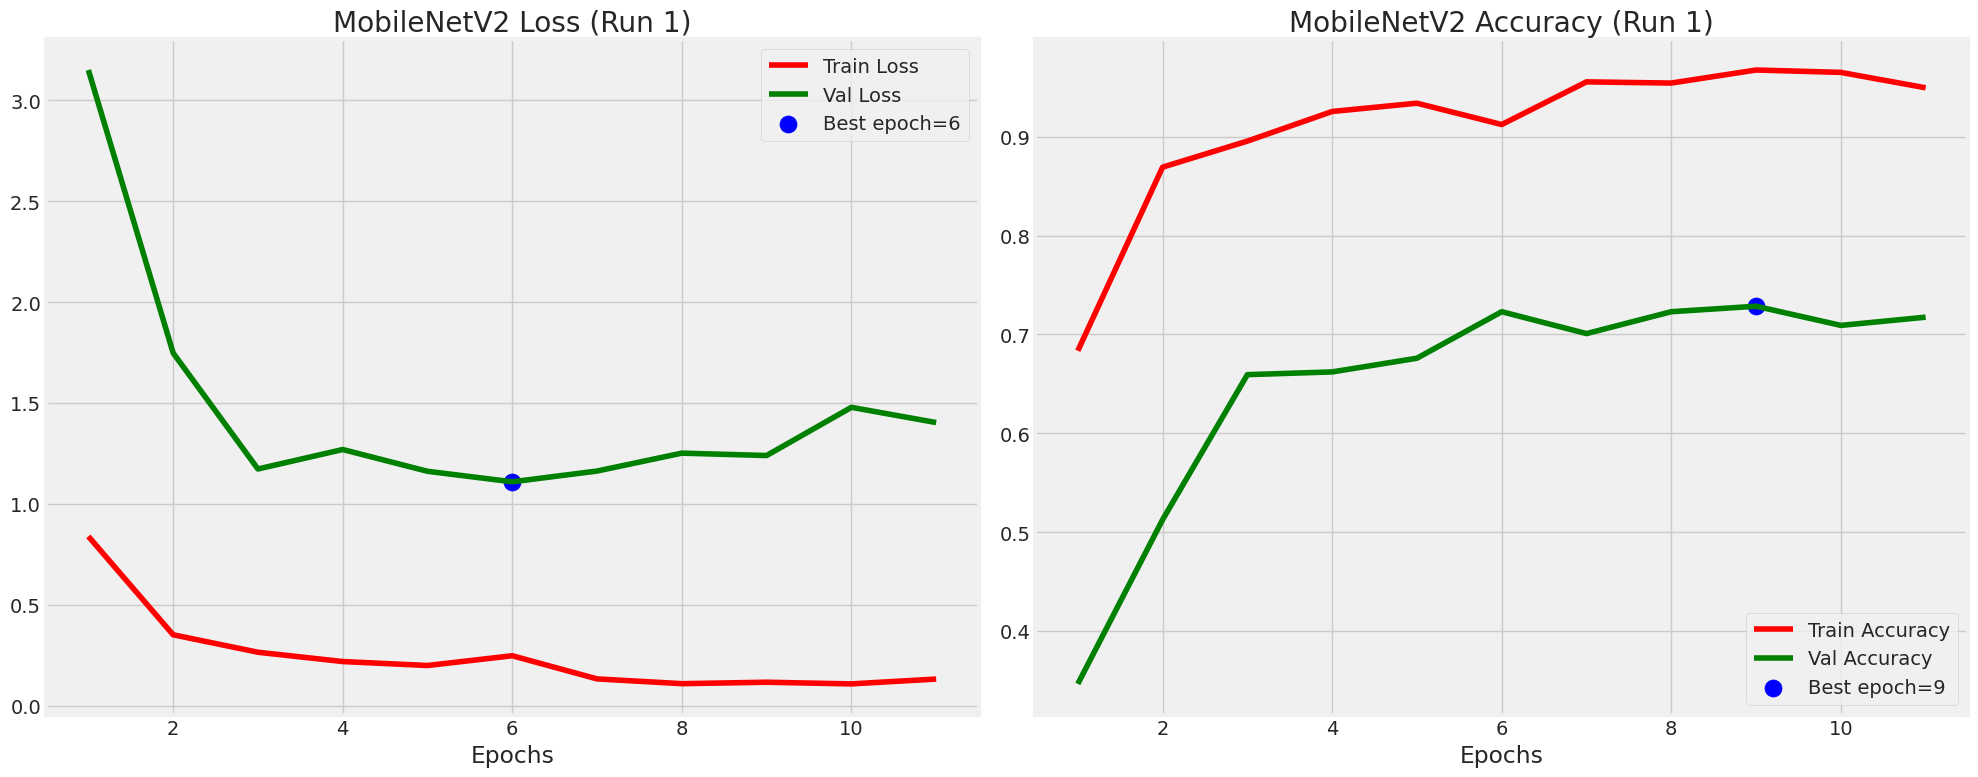

23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 308ms/step
              precision    recall  f1-score   support

      benign       0.81      0.80      0.81       260
   malignant       0.50      0.51      0.51       101

    accuracy                           0.72       361
   macro avg       0.66      0.66      0.66       361
weighted avg       0.72      0.72      0.72       361

23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 264ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 260ms/step - accuracy: 0.7302 - loss: 1.2012


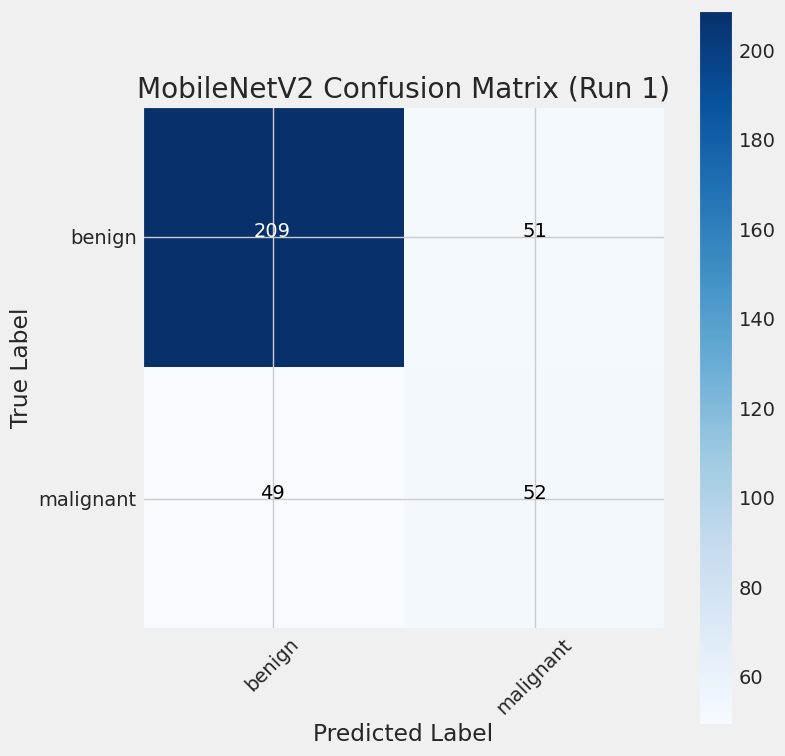

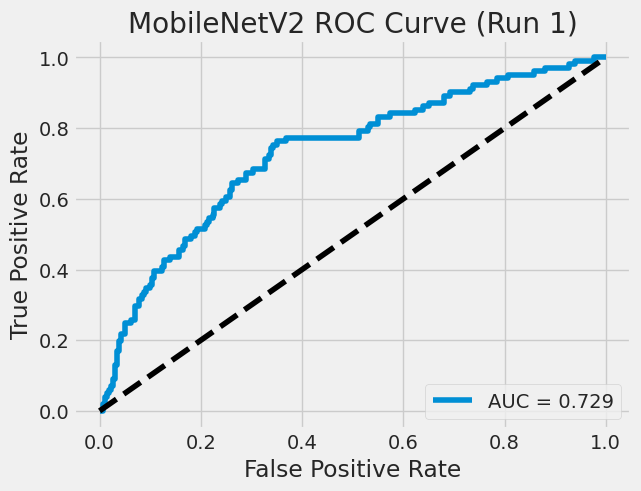


==================================================  MobileNetV2 Run 1
  test_loss                   : 1.1420
  test_accuracy               : 0.7138
  sensitivity                 : 0.5149
  PPV                         : 0.5049
  NPV                         : 0.8101
  AUC                         : 0.7291
  inference_time              : 0.0177
  f1_benign                   : 0.8069
  f1_malignant                : 0.5098
  precision_benign            : 0.8101
  recall_benign               : 0.8038
  precision_malignant         : 0.5049
  recall_malignant            : 0.5149

--- ResNet50 (Run 1) ---
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,646,018 (94.02 MB)

 Trainable params: 1,054,210 (4.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.6858 - loss: 1.1230 - val_accuracy: 0.7701 - val_loss: 2.3603
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8532 - loss: 0.7037 - val_accuracy: 0.7701 - val_loss: 1.4255
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9093 - loss: 0.2338 - val_accuracy: 0.7673 - val_loss: 1.1146
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9643 - loss: 0.1193 - val_accuracy: 0.7867 - val_loss: 1.0797
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9317 - loss: 0.2174 - val_accuracy: 0.7839 - val_loss: 1.2091
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9380 - loss: 0.1647 - val_accuracy: 0.7701 - val_loss: 1.4323
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9331 - loss: 0.3127 - val_accuracy: 0.7618 - val_loss: 1.5464
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9144 - loss: 0.4208 - val_accuracy: 0.7645 - val_loss:

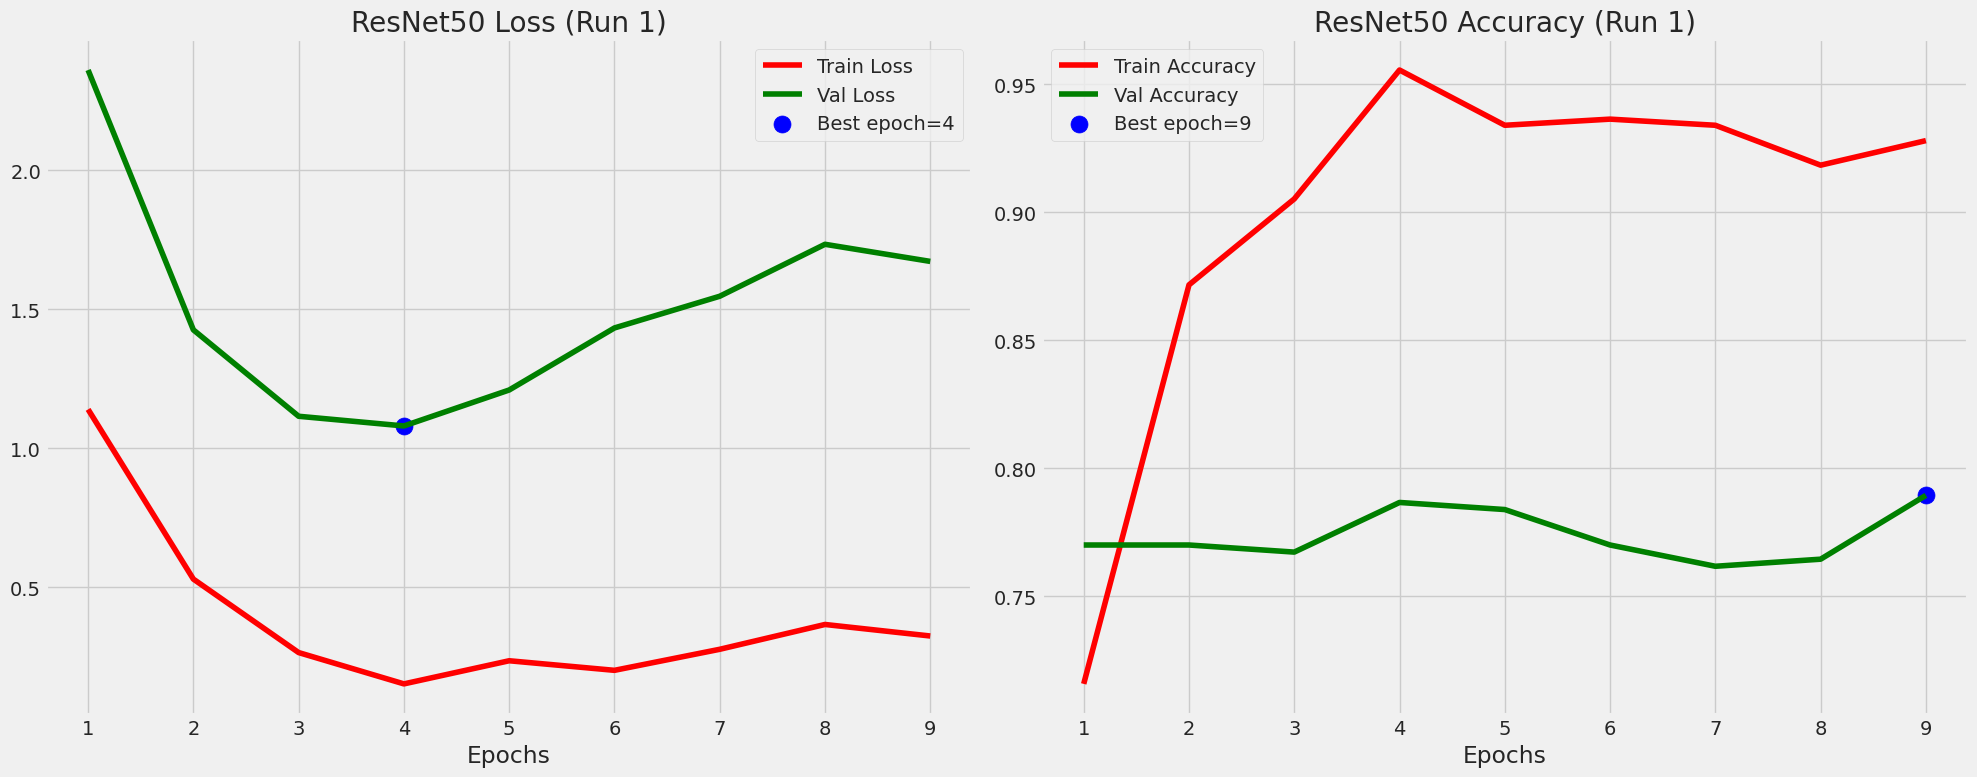

23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step
              precision    recall  f1-score   support

      benign       0.82      0.90      0.86       260
   malignant       0.66      0.50      0.56       101

    accuracy                           0.79       361
   macro avg       0.74      0.70      0.71       361
weighted avg       0.78      0.79      0.78       361

23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8131 - loss: 1.0813


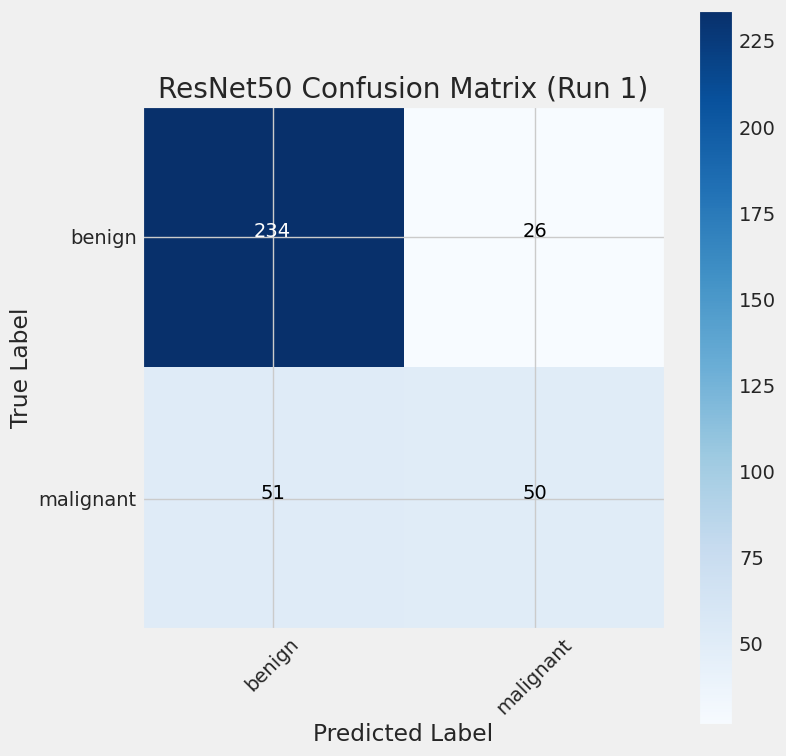

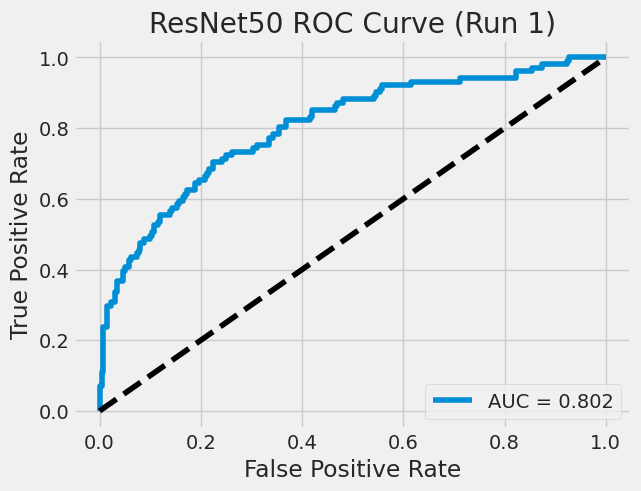


==================================================  ResNet50 Run 1
  test_loss                   : 1.1100
  test_accuracy               : 0.7928
  sensitivity                 : 0.4950
  PPV                         : 0.6579
  NPV                         : 0.8211
  AUC                         : 0.8023
  inference_time              : 0.0673
  f1_benign                   : 0.8587
  f1_malignant                : 0.5650
  precision_benign            : 0.8211
  recall_benign               : 0.9000
  precision_malignant         : 0.6579
  recall_malignant            : 0.4950

############################################################
  RUN 2 / 3
############################################################

Found 834 validated image filenames belonging to 2 classes.
Found 361 validated image filenames belonging to 2 classes.

--- MobileNetV2 (Run 2) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,920,002 (11.14 MB)

 Trainable params: 659,458 (2.52 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 399ms/step - accuracy: 0.6654 - loss: 0.8420 - val_accuracy: 0.4958 - val_loss: 1.8773
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 366ms/step - accuracy: 0.8468 - loss: 0.4307 - val_accuracy: 0.5596 - val_loss: 1.4956
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 371ms/step - accuracy: 0.8762 - loss: 0.3171 - val_accuracy: 0.6842 - val_loss: 1.1134
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 365ms/step - accuracy: 0.9419 - loss: 0.1735 - val_accuracy: 0.6787 - val_loss: 1.1311
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 371ms/step - accuracy: 0.9341 - loss: 0.1841 - val_accuracy: 0.7175 - val_loss: 1.0944
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 361ms/step - accuracy: 0.9533 - loss: 0.1342 - val_accuracy: 0.6842 - val_loss: 1.1923
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 446ms/step - accuracy: 0.9317 - loss: 0.2168 - val_accuracy: 0.7285 - val_loss: 1.2794
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 375ms/step - accuracy: 0.9690 - loss: 0.1008 - val_accuracy: 0.723

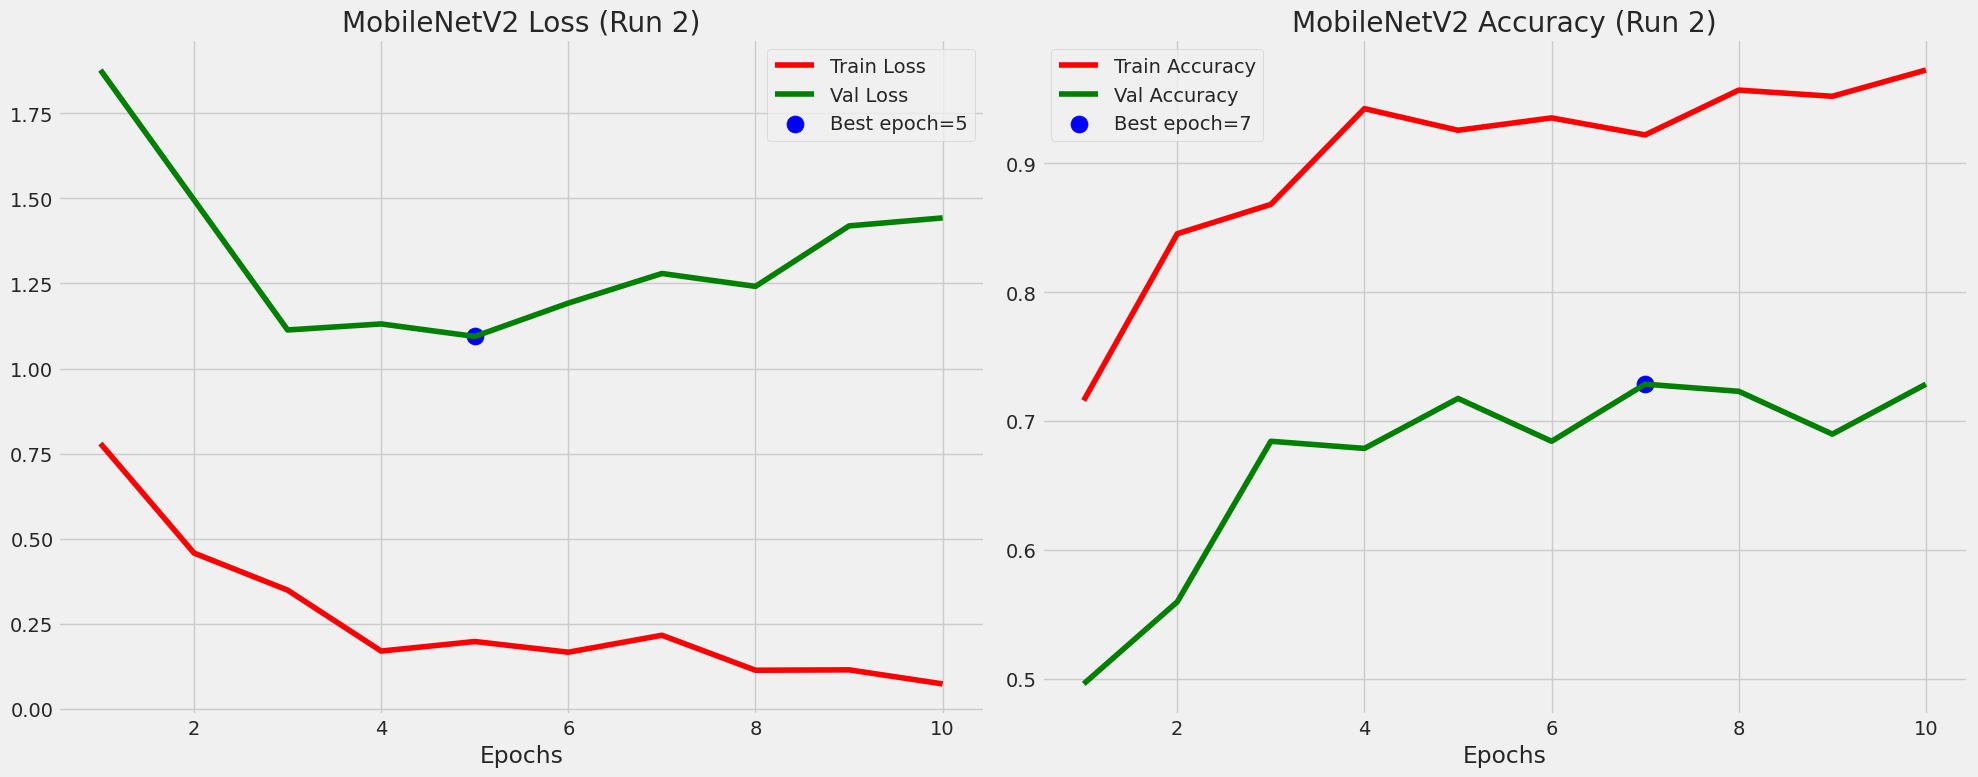

23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 302ms/step
              precision    recall  f1-score   support

      benign       0.79      0.82      0.81       260
   malignant       0.49      0.46      0.47       101

    accuracy                           0.72       361
   macro avg       0.64      0.64      0.64       361
weighted avg       0.71      0.72      0.71       361

23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 249ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 253ms/step - accuracy: 0.6836 - loss: 1.1073


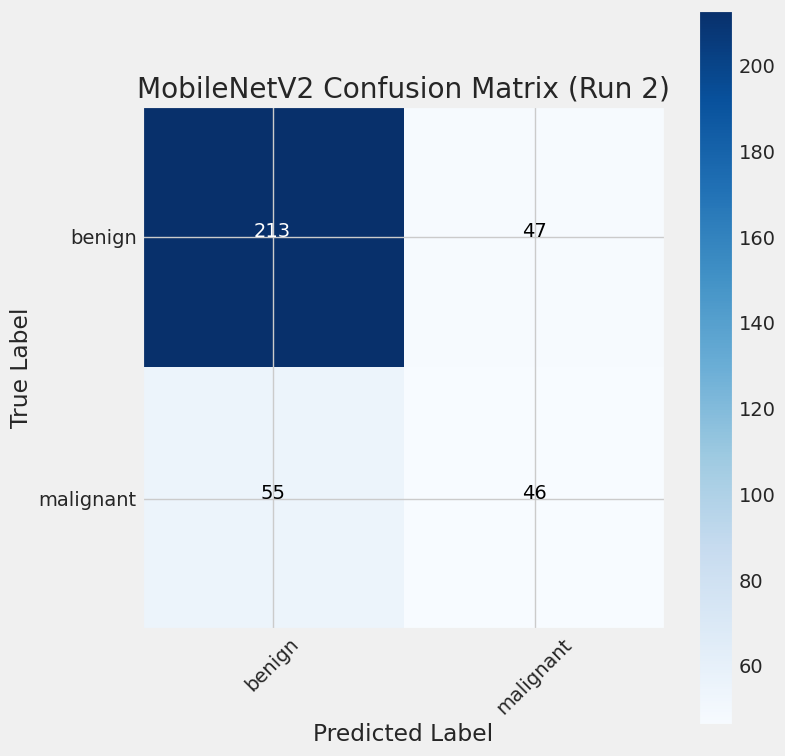

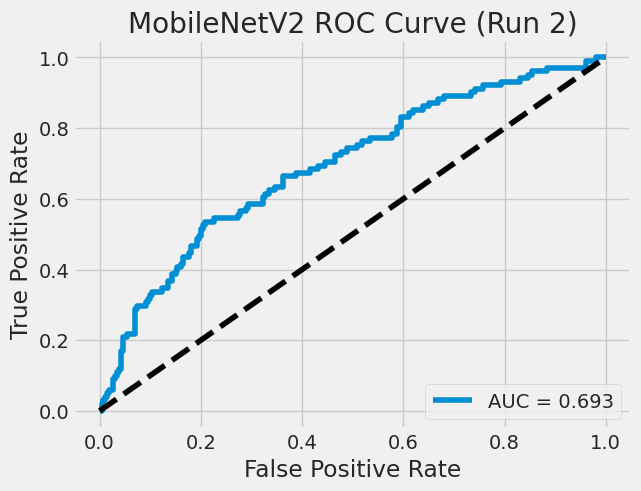


==================================================  MobileNetV2 Run 2
  test_loss                   : 1.1467
  test_accuracy               : 0.6974
  sensitivity                 : 0.4554
  PPV                         : 0.4946
  NPV                         : 0.7948
  AUC                         : 0.6927
  inference_time              : 0.0166
  f1_benign                   : 0.8068
  f1_malignant                : 0.4742
  precision_benign            : 0.7948
  recall_benign               : 0.8192
  precision_malignant         : 0.4946
  recall_malignant            : 0.4554

--- ResNet50 (Run 2) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,646,018 (94.02 MB)

 Trainable params: 1,054,210 (4.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.6955 - loss: 1.1233 - val_accuracy: 0.7590 - val_loss: 1.2574
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.8329 - loss: 0.5925 - val_accuracy: 0.7895 - val_loss: 1.1108
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.8776 - loss: 0.4026 - val_accuracy: 0.7784 - val_loss: 1.3874
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9110 - loss: 0.3108 - val_accuracy: 0.7562 - val_loss: 1.4316
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9352 - loss: 0.2647 - val_accuracy: 0.7839 - val_loss: 1.1606
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.9696 - loss: 0.0884 - val_accuracy: 0.7618 - val_loss: 1.3239
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9649 - loss: 0.1061 - val_accuracy: 0.7784 - val_loss: 1.3577

ResNet50 training time: 596.4s


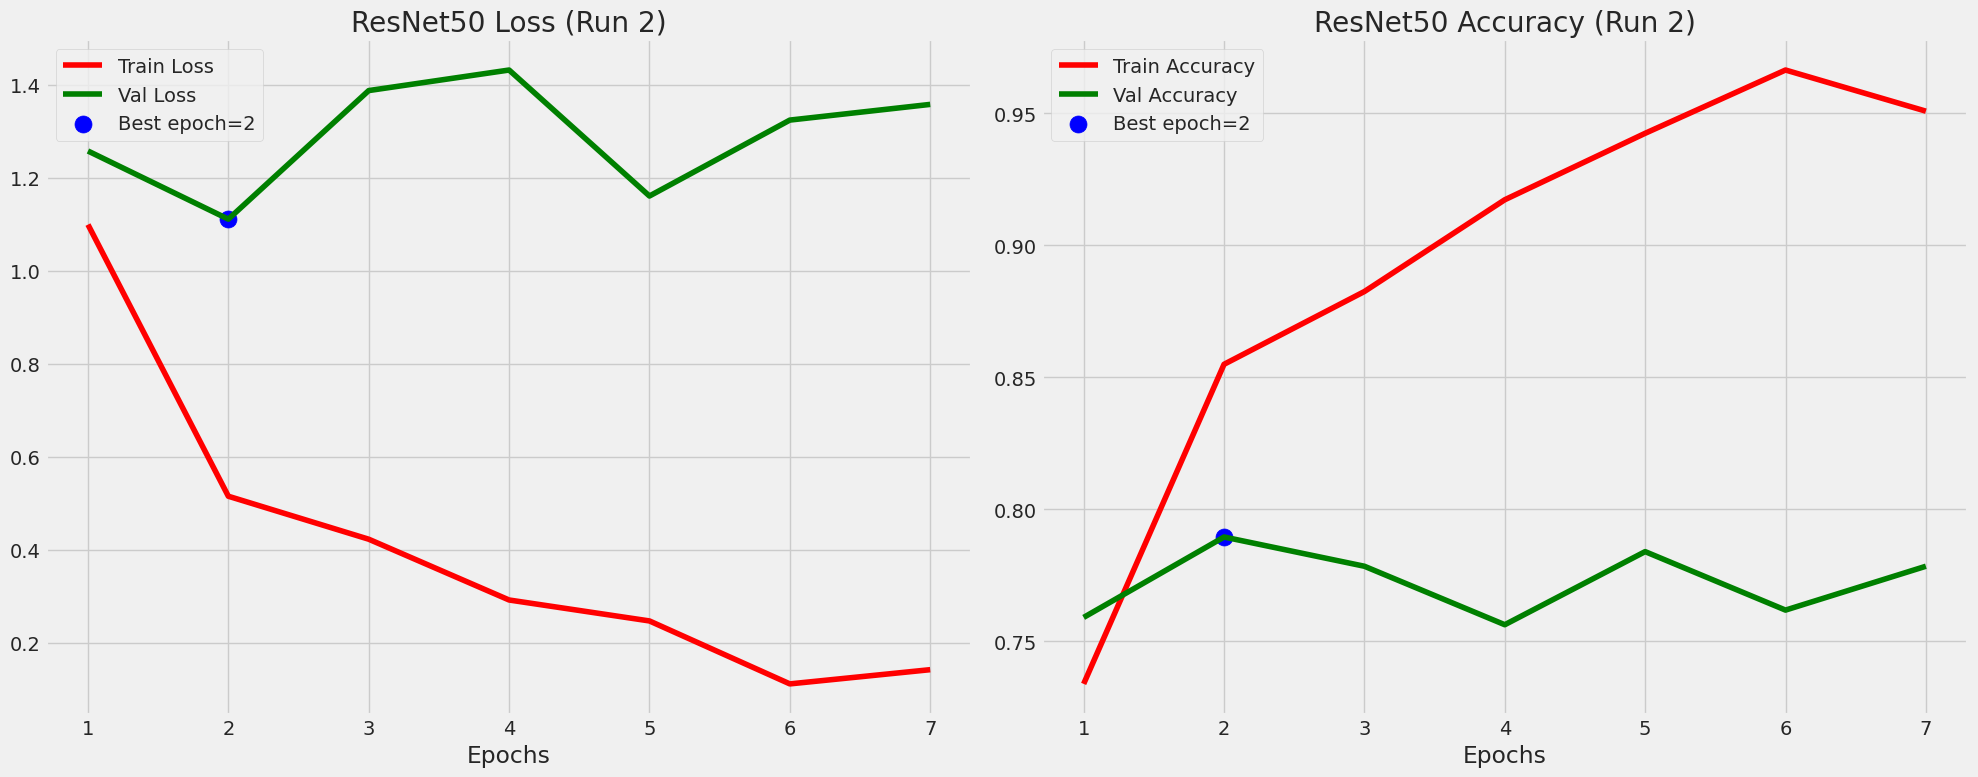

23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step
              precision    recall  f1-score   support

      benign       0.86      0.84      0.85       260
   malignant       0.62      0.65      0.63       101

    accuracy                           0.79       361
   macro avg       0.74      0.75      0.74       361
weighted avg       0.79      0.79      0.79       361

23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7907 - loss: 0.9887


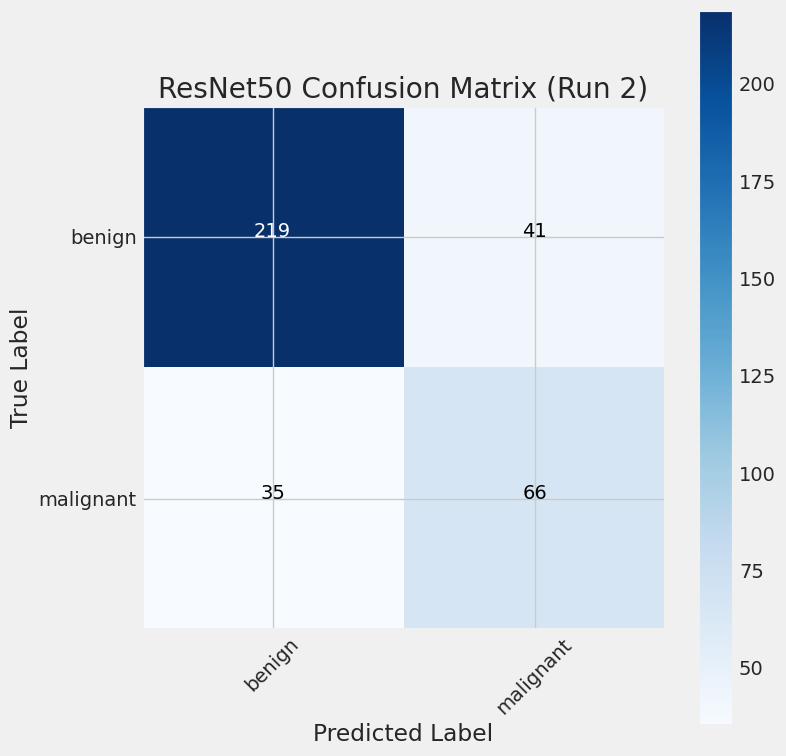

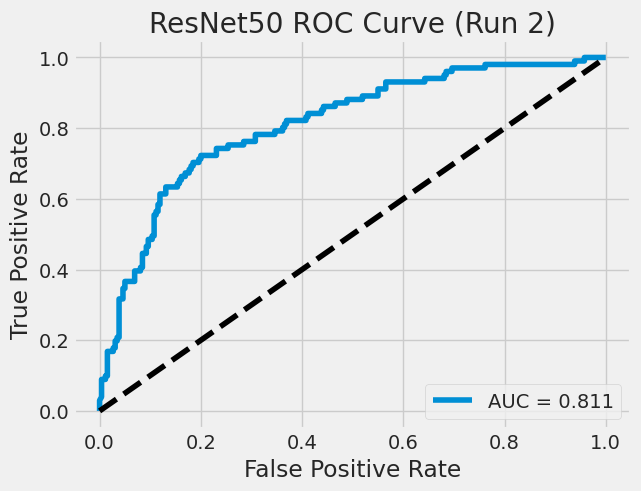


==================================================  ResNet50 Run 2
  test_loss                   : 1.1019
  test_accuracy               : 0.7862
  sensitivity                 : 0.6535
  PPV                         : 0.6168
  NPV                         : 0.8622
  AUC                         : 0.8114
  inference_time              : 0.0700
  f1_benign                   : 0.8521
  f1_malignant                : 0.6346
  precision_benign            : 0.8622
  recall_benign               : 0.8423
  precision_malignant         : 0.6168
  recall_malignant            : 0.6535

############################################################
  RUN 3 / 3
############################################################

Found 834 validated image filenames belonging to 2 classes.
Found 361 validated image filenames belonging to 2 classes.

--- MobileNetV2 (Run 3) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,920,002 (11.14 MB)

 Trainable params: 659,458 (2.52 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 436ms/step - accuracy: 0.6654 - loss: 0.9161 - val_accuracy: 0.5734 - val_loss: 1.1700
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 405ms/step - accuracy: 0.8417 - loss: 0.4311 - val_accuracy: 0.6953 - val_loss: 0.8980
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 402ms/step - accuracy: 0.9009 - loss: 0.3001 - val_accuracy: 0.7285 - val_loss: 0.9475
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 22s 410ms/step - accuracy: 0.9163 - loss: 0.2021 - val_accuracy: 0.7147 - val_loss: 0.9601
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 22s 419ms/step - accuracy: 0.9221 - loss: 0.2374 - val_accuracy: 0.7285 - val_loss: 1.0863
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 22s 406ms/step - accuracy: 0.9099 - loss: 0.2464 - val_accuracy: 0.7147 - val_loss: 1.1996
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 396ms/step - accuracy: 0.9539 - loss: 0.1382 - val_accuracy: 0.7424 - val_loss: 1.2319

MobileNetV2 training time: 157.1s


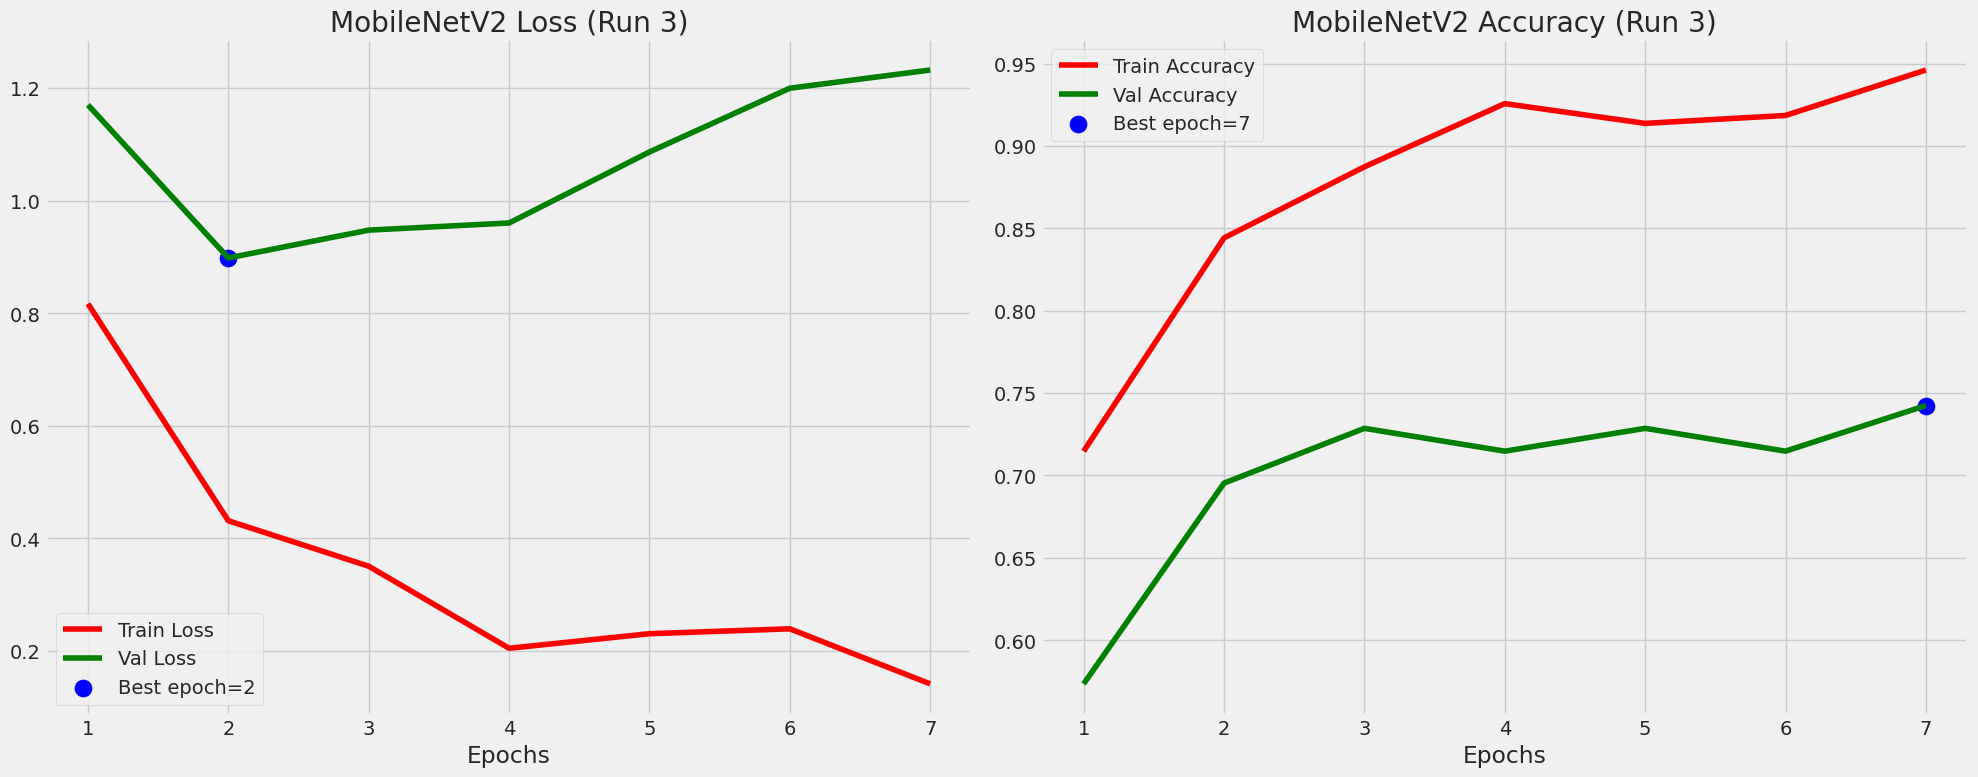

23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 330ms/step
              precision    recall  f1-score   support

      benign       0.79      0.78      0.79       260
   malignant       0.46      0.47      0.46       101

    accuracy                           0.70       361
   macro avg       0.62      0.62      0.62       361
weighted avg       0.70      0.70      0.70       361

23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 303ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 299ms/step - accuracy: 0.6877 - loss: 0.9033


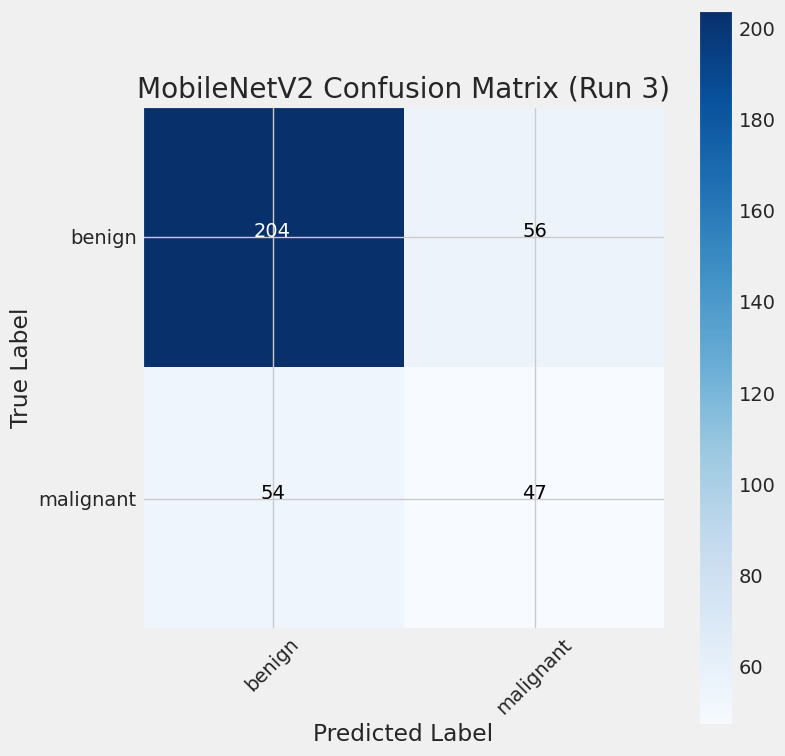

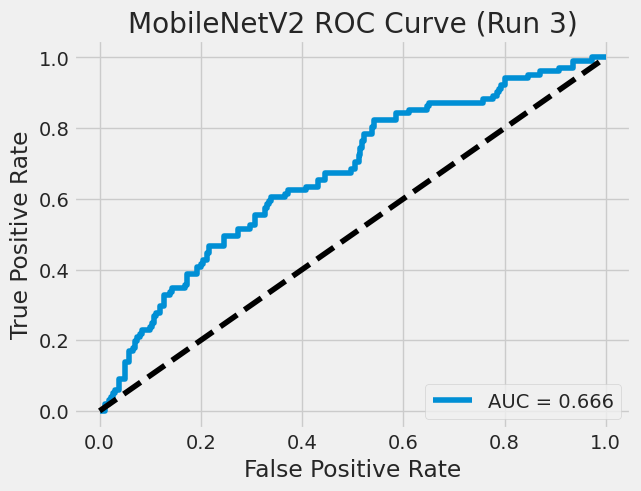


==================================================  MobileNetV2 Run 3
  test_loss                   : 0.9239
  test_accuracy               : 0.6974
  sensitivity                 : 0.4653
  PPV                         : 0.4563
  NPV                         : 0.7907
  AUC                         : 0.6656
  inference_time              : 0.0201
  f1_benign                   : 0.7876
  f1_malignant                : 0.4608
  precision_benign            : 0.7907
  recall_benign               : 0.7846
  precision_malignant         : 0.4563
  recall_malignant            : 0.4653

--- ResNet50 (Run 3) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,646,018 (94.02 MB)

 Trainable params: 1,054,210 (4.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.6744 - loss: 1.1195 - val_accuracy: 0.7590 - val_loss: 1.2803
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.8850 - loss: 0.3788 - val_accuracy: 0.7729 - val_loss: 1.0027
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9271 - loss: 0.2147 - val_accuracy: 0.7618 - val_loss: 1.3472
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9313 - loss: 0.2081 - val_accuracy: 0.7673 - val_loss: 1.3872
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.9499 - loss: 0.1864 - val_accuracy: 0.7701 - val_loss: 1.5541
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.9499 - loss: 0.1762 - val_accuracy: 0.7645 - val_loss: 1.3565
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.9524 - loss: 0.1687 - val_accuracy: 0.7535 - val_loss: 1.4313

ResNet50 training time: 771.8s


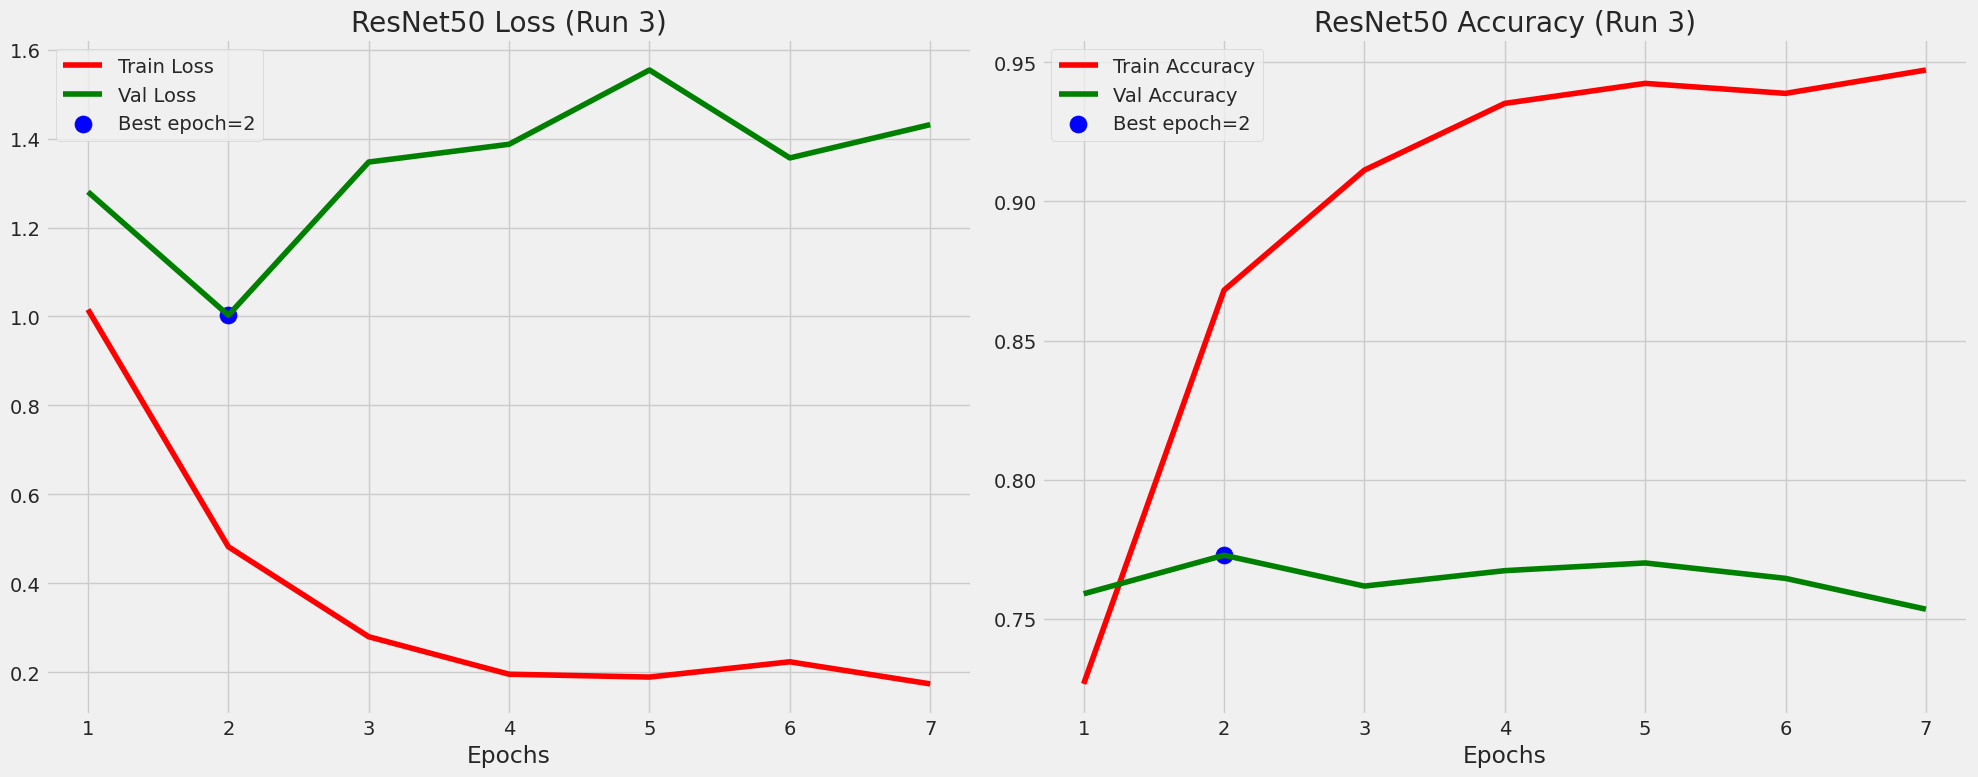

23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step
              precision    recall  f1-score   support

      benign       0.83      0.86      0.84       260
   malignant       0.60      0.55      0.58       101

    accuracy                           0.77       361
   macro avg       0.72      0.71      0.71       361
weighted avg       0.77      0.77      0.77       361

23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7586 - loss: 1.0094


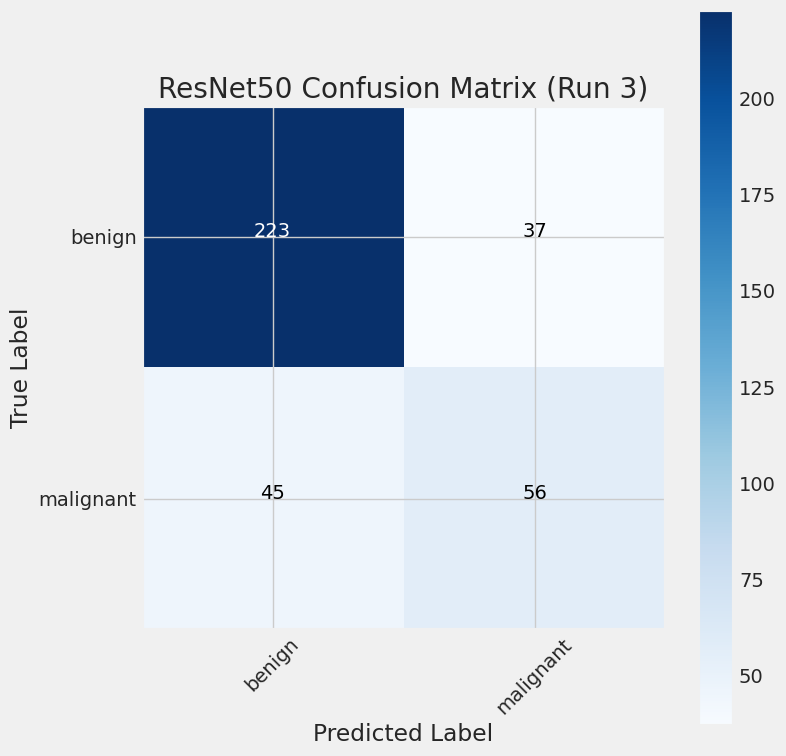

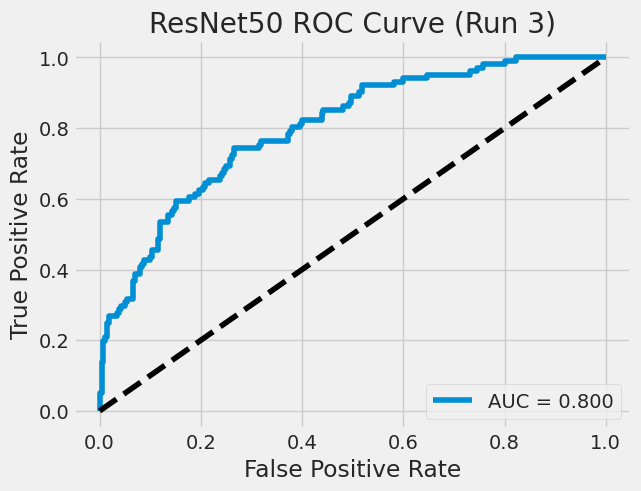


==================================================  ResNet50 Run 3
  test_loss                   : 1.0279
  test_accuracy               : 0.7697
  sensitivity                 : 0.5545
  PPV                         : 0.6022
  NPV                         : 0.8321
  AUC                         : 0.7995
  inference_time              : 0.0695
  f1_benign                   : 0.8447
  f1_malignant                : 0.5773
  precision_benign            : 0.8321
  recall_benign               : 0.8577
  precision_malignant         : 0.6022
  recall_malignant            : 0.5545


In [13]:
all_results = {'MobileNetV2': [], 'ResNet50': []}

for run in range(1, N_RUNS + 1):
    print(f"\n{'#'*60}\n  RUN {run} / {N_RUNS}\n{'#'*60}\n")
    tf.keras.backend.clear_session(); gc.collect()

    train_gen, test_gen = build_generators(train_df_balanced, test_df)
    classes     = list(train_gen.class_indices.keys())
    class_count = len(classes)
    early_stop  = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    print(f"\n--- MobileNetV2 (Run {run}) ---")
    model_mv2 = build_mobilenetv2(IMG_SHAPE, class_count)
    model_mv2.summary()
    t0 = time.time()
    hist_mv2 = model_mv2.fit(train_gen, epochs=EPOCHS, verbose=1,
                              validation_data=test_gen, callbacks=[early_stop], shuffle=False)
    print(f"\nMobileNetV2 training time: {time.time()-t0:.1f}s")
    plot_history(hist_mv2, 'MobileNetV2', run)
    m1 = evaluate_model(model_mv2, test_gen, classes, 'MobileNetV2', run)
    mv2_path = f'/kaggle/working/mobilenetv2_run{run}.keras'
    model_mv2.save(mv2_path)
    m1['model_size_MB'] = os.path.getsize(mv2_path) / (1024 * 1024)
    all_results['MobileNetV2'].append(m1)
    del model_mv2; gc.collect(); tf.keras.backend.clear_session()

    print(f"\n--- ResNet50 (Run {run}) ---")
    model_rn50 = build_resnet50(IMG_SHAPE, class_count)
    model_rn50.summary()
    t0 = time.time()
    hist_rn50 = model_rn50.fit(train_gen, epochs=EPOCHS, verbose=1,
                                validation_data=test_gen, callbacks=[early_stop], shuffle=False)
    print(f"\nResNet50 training time: {time.time()-t0:.1f}s")
    plot_history(hist_rn50, 'ResNet50', run)
    m2 = evaluate_model(model_rn50, test_gen, classes, 'ResNet50', run)
    rn50_path = f'/kaggle/working/resnet50_run{run}.keras'
    model_rn50.save(rn50_path)
    m2['model_size_MB'] = os.path.getsize(rn50_path) / (1024 * 1024)
    all_results['ResNet50'].append(m2)
    del model_rn50; gc.collect()

## 13. Mean Results Across All Runs

In [14]:
metric_keys = ['test_loss','test_accuracy','sensitivity','PPV','NPV','AUC',
               'inference_time','f1_benign','f1_malignant','precision_benign',
               'recall_benign','precision_malignant','recall_malignant','model_size_MB']

summary_rows = []
for model_name, runs in all_results.items():
    row = {'Model': model_name}
    for k in metric_keys:
        vals = [r[k] for r in runs if k in r]
        row[f'{k}_mean'] = np.mean(vals)
        row[f'{k}_std']  = np.std(vals)
    summary_rows.append(row)

pd.DataFrame(summary_rows).to_csv('/kaggle/working/mean_results_summary.csv', index=False)

print(f"{'='*60}\n  MEAN RESULTS — Derm7pt\n{'='*60}")
for row in summary_rows:
    print(f"\n{row['Model']}:")
    for k in metric_keys:
        print(f"  {k:<30}: {row[f'{k}_mean']:.4f} +/- {row[f'{k}_std']:.4f}")
print("\nSaved -> /kaggle/working/mean_results_summary.csv")

  MEAN RESULTS — Derm7pt

MobileNetV2:
  test_loss                     : 1.0708 +/- 0.1039
  test_accuracy                 : 0.7029 +/- 0.0078
  sensitivity                   : 0.4785 +/- 0.0260
  PPV                           : 0.4853 +/- 0.0209
  NPV                           : 0.7985 +/- 0.0083
  AUC                           : 0.6958 +/- 0.0260
  inference_time                : 0.0182 +/- 0.0015
  f1_benign                     : 0.8005 +/- 0.0091
  f1_malignant                  : 0.4816 +/- 0.0207
  precision_benign              : 0.7985 +/- 0.0083
  recall_benign                 : 0.8026 +/- 0.0142
  precision_malignant           : 0.4853 +/- 0.0209
  recall_malignant              : 0.4785 +/- 0.0260
  model_size_MB                 : 16.7390 +/- 0.0000

ResNet50:
  test_loss                     : 1.0799 +/- 0.0370
  test_accuracy                 : 0.7829 +/- 0.0097
  sensitivity                   : 0.5677 +/- 0.0653
  PPV                           : 0.6256 +/- 0.0236
  NPV        

## 14. Final Comparison Table

In [15]:
display_metrics = ['test_accuracy','sensitivity','PPV','NPV','AUC',
                   'f1_malignant','inference_time','model_size_MB']
model_names = list(all_results.keys())
table_data  = {}
for k in display_metrics:
    table_data[k] = []
    for mn in model_names:
        row = next(r for r in summary_rows if r['Model'] == mn)
        table_data[k].append(f"{row[f'{k}_mean']:.4f} +/- {row[f'{k}_std']:.4f}")

comparison_df = pd.DataFrame(table_data, index=model_names).T
comparison_df.index.name = 'Metric'
print(comparison_df.to_string())
comparison_df

                       MobileNetV2             ResNet50
Metric                                                 
test_accuracy    0.7029 +/- 0.0078    0.7829 +/- 0.0097
sensitivity      0.4785 +/- 0.0260    0.5677 +/- 0.0653
PPV              0.4853 +/- 0.0209    0.6256 +/- 0.0236
NPV              0.7985 +/- 0.0083    0.8384 +/- 0.0174
AUC              0.6958 +/- 0.0260    0.8044 +/- 0.0051
f1_malignant     0.4816 +/- 0.0207    0.5923 +/- 0.0303
inference_time   0.0182 +/- 0.0015    0.0689 +/- 0.0012
model_size_MB   16.7390 +/- 0.0000  102.6959 +/- 0.0000


,MobileNetV2,ResNet50
Metric,,
test_accuracy,0.7029 +/- 0.0078,0.7829 +/- 0.0097
sensitivity,0.4785 +/- 0.0260,0.5677 +/- 0.0653
PPV,0.4853 +/- 0.0209,0.6256 +/- 0.0236
NPV,0.7985 +/- 0.0083,0.8384 +/- 0.0174
AUC,0.6958 +/- 0.0260,0.8044 +/- 0.0051
f1_malignant,0.4816 +/- 0.0207,0.5923 +/- 0.0303
inference_time,0.0182 +/- 0.0015,0.0689 +/- 0.0012
model_size_MB,16.7390 +/- 0.0000,102.6959 +/- 0.0000
